Background:

As a talent sourcing and management company, we are interested in finding talented individuals for sourcing these candidates to technology companies. Finding talented candidates is not easy, for several reasons. The first reason is one needs to understand what the role is very well to fill in that spot, this requires understanding the client’s needs and what they are looking for in a potential candidate. The second reason is one needs to understand what makes a candidate shine for the role we are in search for. Third, where to find talented individuals is another challenge.

The nature of our job requires a lot of human labor and is full of manual operations. Towards automating this process we want to build a better approach that could save us time and finally help us spot potential candidates that could fit the roles we are in search for. Moreover, going beyond that for a specific role we want to fill in we are interested in developing a machine learning powered pipeline that could spot talented individuals, and rank them based on their fitness.

We are right now semi-automatically sourcing a few candidates, therefore the sourcing part is not a concern at this time but we expect to first determine best matching candidates based on how fit these candidates are for a given role. We generally make these searches based on some keywords such as “full-stack software engineer”, “engineering manager” or “aspiring human resources” based on the role we are trying to fill in. These keywords might change, and you can expect that specific keywords will be provided to you.

Assuming that we were able to list and rank fitting candidates, we then employ a review procedure, as each candidate needs to be reviewed and then determined how good a fit they are through manual inspection. This procedure is done manually and at the end of this manual review, we might choose not the first fitting candidate in the list but maybe the 7th candidate in the list. If that happens, we are interested in being able to re-rank the previous list based on this information. This supervisory signal is going to be supplied by starring the 7th candidate in the list. Starring one candidate actually sets this candidate as an ideal candidate for the given role. Then, we expect the list to be re-ranked each time a candidate is starred.

**Data Description** :

The data comes from our sourcing efforts. We removed any field that could directly reveal personal details and gave a unique identifier for each candidate.

**Attributes**:
id : unique identifier for candidate (numeric)

job_title : job title for candidate (text)

location : geographical location for candidate (text)

connections: number of connections candidate has, 500+ means over 500 (text)

**Output (desired target)**:
fit - how fit the candidate is for the role? (numeric, probability between 0-1)

Keywords: “Aspiring human resources” or “seeking human resources”

Download Data:

https://docs.google.com/spreadsheets/d/117X6i53dKiO7w6kuA1g1TpdTlv1173h_dPlJt5cNNMU/edit?usp=sharing

**Goal(s)**:

Predict how fit the candidate is based on their available information (variable fit)

Success Metric(s):

Rank candidates based on a fitness score.

Re-rank candidates when a candidate is starred.

Current Challenges:

We are interested in a robust algorithm, tell us how your solution works and show us how your ranking gets better with each starring action.

How can we filter out candidates which in the first place should not be in this list?

Can we determine a cut-off point that would work for other roles without losing high potential candidates?

Do you have any ideas that we should explore so that we can even automate this procedure to prevent human bias?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/potential-talents - Aspiring human resources - seeking human resources.csv')

In [ ]:
df=data.copy()

In [ ]:
df.head()

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [ ]:
df.shape

(104, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null    object 
 3   connection  104 non-null    object 
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.2+ KB


* •	The fit column is entirely null (0 non-null counts), which means it contains no data.
* Connection column is object data type.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,104.000,52.500,30.166,1.000,26.750,52.500,78.250,104.000
fit,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
job_title,104,52,2019 C.T. Bauer College of Business Graduate (...,7
location,104,41,Kanada,12
connection,104,33,500+,44


* There are 104 entries, but only 52 unique job titles. The top job titles like "2019 C.T. Bauer College of Business Graduate..." 7 times
* There are 104 entries with 41 unique locations. "Kanada" (Canada) is the most frequent location with 12 occurrences
* connection column has 104 entries and 33 unique values. The most frequent value is "500+" (44 times), which represents candidates with over 500 connections.

In [ ]:
df.isnull().sum()

,0
id,0
job_title,0
location,0
connection,0
fit,104



2. Categorical Columns:

Value counts for 'job_title' column (top 10):
job_title
2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional    7
Aspiring Human Resources Professional                                                                       7
Student at Humber College and Aspiring Human Resources Generalist                                           7
People Development Coordinator at Ryan                                                                      6
Native English Teacher at EPIK (English Program in Korea)                                                   5
Aspiring Human Resources Specialist                                                                         5
HR Senior Specialist                                                                                        5
Advisory Board Member at Celal Bayar University                                                             4
Seeking Human Resources HRIS and Gener

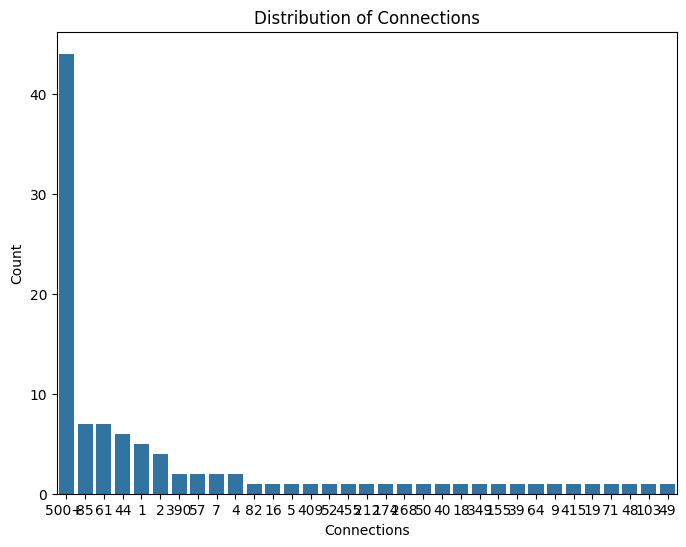

In [ ]:
print("\n2. Categorical Columns:")
print("\nValue counts for 'job_title' column (top 10):")
print(df['job_title'].value_counts().head(10))

print("\nValue counts for 'location' column (top 10):")
print(df['location'].value_counts().head(10))

print("\nValue counts for 'connection' column:")
print(df['connection'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='connection', order=df['connection'].value_counts().index)
plt.title('Distribution of Connections')
plt.xlabel('Connections')
plt.ylabel('Count')
plt.show()

In [ ]:

# Converting the 'connection' column to a numerical format
df['connection'] = df['connection'].str.replace('500+', '500').astype(int)

print(df['connection'].value_counts())
print(df['connection'].dtype)

connection
500    44
85      7
61      7
44      6
1       5
2       4
390     2
57      2
7       2
4       2
82      1
16      1
5       1
409     1
52      1
455     1
212     1
174     1
268     1
50      1
40      1
18      1
349     1
155     1
39      1
64      1
9       1
415     1
19      1
71      1
48      1
103     1
49      1
Name: count, dtype: int64
int64


# **Encoding**

## Word2Vec

In [ ]:
# Install gensim if not already installed
!pip install gensim

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import gensim.models
import numpy as np # numpy is used for np.mean and np.zeros

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    # Explicitly download 'punkt_tab' as suggested by the error
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Initialize lemmatizer and stopwords
# It initializes a WordNetLemmatizer to reduce words to their base form (e.g., 'running' to 'run') and loads a set of common English stop_words (like 'the', 'is', 'a') that are usually removed during text processing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    tokens = word_tokenize(text)  # Tokenize
    # Remove stopwords, lemmatize, and remove non-alphabetic tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

# Apply preprocessing to the 'job_title' column
df['processed_job_title'] = df['job_title'].apply(preprocess_text)

# Train Word2Vec model
# min_count: Ignores all words with total frequency lower than this. 2 is a good starting point.
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# sg: Training algorithm: 1 for skip-gram; 0 for CBOW.

word2vec_model = gensim.models.Word2Vec(sentences=df['processed_job_title'],
                                        vector_size=100,
                                        window=5,
                                        min_count=2,
                                        workers=4,
                                        sg=0)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# Function to create document embedding by averaging word vectors
def get_document_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size) # Return a zero vector if no words are in the vocabulary
# Apply the get_average_embedding function to each list of tokens
df['job_title_embedding'] = df['processed_job_title'].apply(lambda tokens: get_document_embedding(tokens, word2vec_model))
df[['job_title', 'job_title_embedding']].head()

,job_title,job_title_embedding
0,2019 C.T. Bauer College of Business Graduate (...,"[0.0016742188, 0.0002734413, 0.0018166878, 0.0..."
1,Native English Teacher at EPIK (English Progra...,"[-4.727114e-05, -0.003282718, 0.0021956472, -0..."
2,Aspiring Human Resources Professional,"[-0.004372496, 0.0039762342, 0.00075248437, 0...."
3,People Development Coordinator at Ryan,"[0.0029596265, 0.0020586422, 0.003301497, -0.0..."
4,Advisory Board Member at Celal Bayar University,"[0.0008259456, -0.004887592, -0.0020814978, 0...."


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_job_titles(query_job_title, df, word2vec_model, top_n=10):
    # Preprocess the query job title
    processed_query = preprocess_text(query_job_title)

    # Get embedding for the query
    query_embedding = get_document_embedding(processed_query, word2vec_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage:
query = "Aspiring Human Resources"
recommended_jobs = recommend_job_titles(query, df, word2vec_model, top_n=10)

print(f"Recommendations for '{query}':\n")
display(recommended_jobs)



Recommendations for 'Aspiring Human Resources':



,job_title,location,connection,similarity
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.885
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.885
35,Aspiring Human Resources Specialist,Greater New York City Area,1,0.885
48,Aspiring Human Resources Specialist,Greater New York City Area,1,0.885
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.885
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.857
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.857
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.857
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.857
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.857


* the output shows several entries for "Aspiring Human Resources Specialist," all with a high similarity score of 0.885. This indicates that our word embedding model effectively captured the close semantic relationship between the query and this particular job title.

## FastText

In [ ]:
from gensim.models import FastText

# Train FastText model
# min_count: Ignores all words with total frequency lower than this. 2 is a good starting point.
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# sg: Training algorithm: 1 for skip-gram; 0 for CBOW. FastText often performs well with skip-gram (sg=1).

fasttext_model = FastText(sentences=df['processed_job_title'],
                          vector_size=100,
                          window=5,
                          min_count=2,
                          workers=4,
                          sg=1) # sg=1 for skip-gram, often preferred for FastText

# Function to create document embedding by averaging word vectors (similar to Word2Vec)
def get_fasttext_document_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size) # Return a zero vector if no words are in the vocabulary

# Apply the get_fasttext_document_embedding function to each list of tokens
df['job_title_fasttext_embedding'] = df['processed_job_title'].apply(lambda tokens: get_fasttext_document_embedding(tokens, fasttext_model))
df[['job_title', 'job_title_fasttext_embedding']].head()



,job_title,job_title_fasttext_embedding
0,2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional,"[-0.00058710534, -0.0004988964, 0.00014342673, 0.0002174234, 0.0009110168, -0.00029983112, 0.00061891903, -0.00013786535, 0.00022015432, -9.557971e-05, 0.00039217444, -9.5267926e-05, 0.0005440931, 0.00023279547, 0.0008109521, -0.0011923877, -0.00040379984, -0.0002774184, 0.0006073234, -0.0006073756, 5.0048155e-05, 1.7835357e-05, 0.00037748076, -8.345772e-05, -0.0001587983, 0.00042928077, -0.00020324043, 0.0002803636, 0.00033722311, 0.00021648138, 4.8371392e-05, 0.00022611846, 0.0004125028, -0.00058475725, -0.0005244352, -0.00029850518, 0.0010372662, 5.1327366e-05, 0.00044963977, -0.0016285476, 0.0003409472, -0.00048110634, 2.2405091e-05, 0.0004609493, 1.127712e-05, 0.0005420845, 0.00075923407, -0.0004749122, 9.995339e-05, 0.00040823323, -0.00084555335, 0.00036134198, -0.0003490432, 0.00059286784, 0.00020119027, 6.20151e-05, -3.696071e-05, 0.0006568693, -0.00064907223, 0.0006480199, 0.0009383609, 0.00046344355, -0.00080923905, -0.0007904244, -0.00013520151, 0.00059656246, -0.00089078076, 0.00018020872, -0.00015230692, 0.0002437624, -0.00014583179, 0.00067990535, -0.00024838856, -4.208087e-05, 0.00013389658, -0.00030843756, 0.00043100992, 0.0009525349, -5.9678398e-05, -8.425876e-05, -0.0010973642, 0.00021537175, -8.6346394e-05, 0.0010450012, 3.4686263e-06, 0.0010947243, 0.00055575545, 0.00012382299, 0.00024630793, 0.0002038125, -0.0002228578, 0.00022171548, 0.0009840082, -0.00042330948, -0.0005031275, 0.0006710466, 2.6284602e-05, 0.00029477978, 0.00028509364, 0.00045200356]"
1,Native English Teacher at EPIK (English Program in Korea),"[-0.0007843928, -0.00056507176, 0.00058506994, -0.0002652769, 0.00029471394, -0.00046942531, -0.00032521348, -0.0009827495, -9.945907e-05, -0.0003648381, -4.4221822e-05, -0.00014394114, -0.0004667616, 0.0011414645, 0.0003934588, -0.000671828, 0.00027479895, 0.0003444857, 0.00061484426, -0.00037762482, -0.00022751848, 0.000407242, -0.0004590006, 0.0006740307, 0.00029074677, -0.00022372363, 0.0010788713, 2.462532e-05, -9.964786e-05, -0.00017257125, -6.843952e-05, 0.0008309123, 0.00011750216, -0.0003677821, -0.0011055445, -0.0011259461, -0.0005306654, 0.0009830099, 0.001882587, -0.0008852486, -0.00097093766, 0.0001579366, -0.00029561532, 0.0009782069, -0.0008808067, -0.00055003335, 0.0004723005, -0.00079431414, -0.0005665119, -0.00050888705, 0.0003212423, -0.0007852218, -0.0002180102, 1.641035e-05, 0.00054415275, 0.00044997703, -0.0006367319, -0.0008311648, -0.0005990364, 0.0006369733, -0.0006383374, 0.0006083155, 0.0004856037, -0.0004835783, -0.00051212235, -0.0010613538, -0.0012273426, 0.0001175159, 0.0007684185, 6.6499e-05, 0.00020493772, 0.00068815023, 0.0007277778, -0.000251987, -0.0002578512, -0.00048870913, 0.00015089776, -3.2493178e-06, -0.00031987656, 0.0017721065, -0.0016280535, 8.571677e-05, 0.0004972841, 0.0015393338, -0.00041691927, 0.000691731, -2.9792658e-05, -0.0004092, 0.00048175993, 0.00092492916, -0.001312916, -6.7469955e-07, 0.00057055306, 0.00061415054, -0.00020169902, 0.00028263923, -3.9268085e-05, -0.00022753615, 0.0002649923, -0.0014557828]"
2,Aspiring Human Resources Professional,"[-0.00028548794, -0.00068620057, 0.00027034123, -0.0008516578, -0.00033472307, -0.00012679139, 9.16803e-05, -0.00055556884, 0.00026325302, 0.00039679586, 0.00088841066, 6.825077e-05, 0.00051866245, 0.00020713234, 0.00058036274, -0.00022990412, -0.00069542066, 0.00060449465, -0.0010998145, -0.0006246312, 0.00018904157, -0.0003630291, -0.00038713403, 0.00014029373, -0.00090130273, -9.507156e-05, -0.00047125784, 0.0004985363, -0.0006581497, -0.0005170122, 0.00031004346, 0.00052209315, 0.00074537855, -0.0009591342, -0.000909809, -0.0012129141, 0.0017078327, -0.0006131921, 0.00063021574, -0.0005922619, 8.047934e-05, -0.00026170787, -8.353993e-06, -6.0465274e-05, -0.00015281646, 0.0014295403, 0.0017577324, 0.00064648653, 0.0004102788, 0.00033762667, -0.00084000

In [ ]:
def recommend_job_titles_fasttext(query_job_title, df, fasttext_model, top_n=10):
    # Preprocess the query job title
    processed_query = preprocess_text(query_job_title)

    # Get embedding for the query
    query_embedding = get_fasttext_document_embedding(processed_query, fasttext_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_fasttext_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage with FastText:
query_fasttext = "Aspiring Human Resources"
recommended_jobs_fasttext = recommend_job_titles_fasttext(query_fasttext, df, fasttext_model, top_n=10)

print(f"Recommendations for '{query_fasttext}' using FastText:")
display(recommended_jobs_fasttext)

Recommendations for 'Aspiring Human Resources' using FastText:


,job_title,location,connection,similarity
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.935
32,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.935
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.935
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.935
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.935
96,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.935
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.935
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.916
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.916
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.916


 * the similarity scores for FastText (e.g., 0.935) are generally higher than those observed with Word2Vec (e.g., 0.885) for similar job titles. This can indicate that FastText, by considering character n-grams, might capture nuances or handle variations in job titles more effectively, leading to potentially stronger semantic matches.

## GLOVE

In [ ]:
import gensim.downloader as api

# Download a pre-trained GloVe model. This can take some time.
# We'll use a smaller version (50-dimensional vectors) for demonstration.
print("Downloading GloVe model... This may take a few minutes.")
try:
    glove_model = api.load("glove-wiki-gigaword-50")
    print("GloVe model downloaded successfully.")
except Exception as e:
    print(f"Error downloading GloVe model: {e}")
    print("Please ensure you have an active internet connection or try a different model.")
    glove_model = None # Set to None if download fails


# Function to create document embedding by averaging word vectors from GloVe
def get_glove_document_embedding(tokens, model):
    if model is None: # Handle case where model download failed
        return np.zeros(50) # Return a zero vector of appropriate size
    vectors = [model[word] for word in tokens if word in model.key_to_index]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words are in the vocabulary or model is None
        return np.zeros(model.vector_size if model else 50)

# Apply the get_glove_document_embedding function to each list of tokens
if glove_model:
    df['job_title_glove_embedding'] = df['processed_job_title'].apply(lambda tokens: get_glove_document_embedding(tokens, glove_model))
    print(df[['job_title', 'job_title_glove_embedding']].head())
else:
    print("GloVe model not available. Cannot create embeddings.")
    df['job_title_glove_embedding'] = [np.zeros(50)] * len(df) # Add a dummy column to avoid errors

def recommend_job_titles_glove(query_job_title, df, glove_model, top_n=10):
    if glove_model is None:
        print("GloVe model is not loaded. Cannot provide recommendations.")
        return pd.DataFrame(columns=['job_title', 'location', 'connection', 'similarity'])

    # Preprocess the query job title
    processed_query = preprocess_text(query_job_title)

    # Get embedding for the query
    query_embedding = get_glove_document_embedding(processed_query, glove_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Filter out rows where job_title_glove_embedding is all zeros (if any failed to get embeddings)
    valid_embeddings_df = df[df['job_title_glove_embedding'].apply(lambda x: not np.all(x == 0))].copy()

    if valid_embeddings_df.empty:
        print("No valid GloVe embeddings found for recommendations.")
        return pd.DataFrame(columns=['job_title', 'location', 'connection', 'similarity'])

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(valid_embeddings_df['job_title_glove_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = valid_embeddings_df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage with GloVe:
query_glove = "Aspiring Human Resources"
recommended_jobs_glove = recommend_job_titles_glove(query_glove, df, glove_model, top_n=10)

print(f"\nRecommendations for '{query_glove}' using GloVe:")
display(recommended_jobs_glove)

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe model downloaded successfully.
                                                                                                  job_title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       job_title_glove_embedding
0  2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional  [-0.6614713, 0.7588564, -0.3328181, -0.

,job_title,location,connection,similarity
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.970
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.970
35,Aspiring Human Resources Specialist,Greater New York City Area,1,0.970
48,Aspiring Human Resources Specialist,Greater New York City Area,1,0.970
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.970
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.959
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.959
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.959
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.959
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.959


# BERT

In [ ]:
!pip install transformers torch

from transformers import BertTokenizer, BertModel
import torch

# Load pre-trained BERT model and tokenizer
print("Loading BERT tokenizer and model...")
tokenizer = BertTokenizer.from_pretrained('distilbert-base-uncased')
model = BertModel.from_pretrained('distilbert-base-uncased')
print("BERT model loaded successfully.")

# Function to get BERT embeddings for a given text
def get_bert_document_embedding(text, tokenizer, model):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the mean of the last hidden states as the document embedding
    # Or, you can use the [CLS] token embedding: outputs.last_hidden_state[:, 0, :].squeeze().numpy()
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

# Apply the get_bert_document_embedding function to the 'job_title' column
print("Generating BERT embeddings for job titles...")
df['job_title_bert_embedding'] = df['job_title'].apply(lambda x: get_bert_document_embedding(x, tokenizer, model))
print("BERT embeddings generated.")

df[['job_title', 'job_title_bert_embedding']].head()


Loading BERT tokenizer and model...


You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


Loading weights: 0it [00:00, ?it/s]

BertModel LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.b

BERT model loaded successfully.
Generating BERT embeddings for job titles...
BERT embeddings generated.


,job_title,job_title_bert_embedding
0,2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional,"[-0.3004447, 0.6051882, -0.30209637, -0.7096403, 1.3638941, 0.44819477, 0.8618646, -0.6374277, -0.66526836, 0.31203392, 0.5312533, -0.48658267, 1.1105195, -0.46028072, 1.1055377, -0.82211494, 1.157742, 0.9924551, 0.62433314, -0.30944005, -1.1364762, 0.3192427, 0.31996763, -0.111514695, 0.23544861, 0.0052081104, -1.3804195, 1.2312219, -0.68813413, -0.061890114, -0.025151206, -0.10762756, -1.5154395, -0.7256168, 0.114334635, -1.5321678, 0.25464657, 0.39669427, 0.8236292, 1.6055528, -0.27865526, -0.8587284, -0.09971635, -0.99547666, -1.2390084, 0.35885045, 0.22285028, -0.8893251, -0.093892224, -1.217559, -0.39719126, -0.15507561, 0.35426563, 0.8662131, 1.0907954, -0.61537325, 0.15969867, -0.21845259, 0.46918157, -0.6232004, 0.043812193, -0.96867937, 0.9498449, -0.35686222, 0.108753875, 0.8167312, -0.09153389, -0.9192906, 0.76185954, 0.1285461, -0.9414579, 0.48462364, -0.17441653, 0.3599811, -0.49815416, -2.3704202, -0.11859057, 0.024678908, 2.2229323, 1.2280816, 0.1363932, -2.0048773, 0.8246042, -0.759564, 0.31961212, 1.071257, 0.84405, -0.02385232, -0.17267556, 0.5298292, 0.54955906, -0.0051439404, -0.15196818, -0.693629, -0.4883211, -0.30070874, -0.7443319, 0.40857637, 0.22456294, -0.50780123, ...]"
1,Native English Teacher at EPIK (English Program in Korea),"[-0.26964906, 0.7547092, -0.048784573, -0.53627247, 0.8847347, 0.8913733, 0.45399338, -0.46016052, -0.926423, 0.41424355, 0.53588086, -0.50813586, 1.3661311, -0.14487728, 1.2834463, -0.7504565, 0.8775353, 1.2919102, 0.8434981, -0.28507355, -1.0816472, 0.5508391, 0.085789256, 0.13047911, 0.11078548, -0.14419766, -1.1842968, 0.99472255, -0.72299576, 0.014270372, -0.56418025, -0.36183363, -1.249938, -0.54166114, -0.025820766, -1.2158016, 0.23623882, 0.5305207, 1.102938, 1.4141093, -0.15494658, -0.98622733, 0.3237191, -1.0666764, -1.8833219, 0.15143014, 0.3165831, -1.0576059, 0.0731596, -1.2266358, -0.20765637, -0.16798632, 0.23013856, 1.2614508, 0.9278145, -0.40176, 0.009435309, -0.19140892, 0.43854484, -0.017621083, 0.046572857, -0.7556839, 1.0824271, -0.5338896, -0.19844106, 0.65172535, -0.21318118, -0.8665934, 0.82521755, -0.16509843, -1.0227736, 0.9077906, -0.07380254, 0.7513294, -0.38685438, -2.4115622, -0.6601907, -0.035015266, 2.5867374, 1.170559, 0.1406155, -2.353027, 0.36941347, -0.8124031, 0.49564144, 0.83314186, 0.85611504, -0.3727541, -0.42332736, 0.9655195, 0.5375024, 0.22296944, -0.16557541, -0.7699386, -0.100519165, -0.5658764, -0.7614712, 0.08330888, 0.4420649, -0.6164126, ...]"
2,Aspiring Human Resources Professional,"[-0.58987826, 0.59544456, -0.42616513, -0.6388394, 1.0463668, 1.3606014, 0.8965942, -0.63113075, -0.2120309, 0.9533964, 0.97880596, -0.72948927, 0.44044015, 0.07418642, 0.8312327, -0.5153617, 0.5304323, 0.64874804, 0.11580908, 0.25953016, -0.4144489, 0.15698421, 0.42738768, -0.119887926, 0.41369104, 0.14689761, -1.0127367, 0.10330818, -0.78499794, -0.10753969, -0.11786527, -0.5283857, -1.3466171, -0.43634358, 0.34312972, -1.3859798, 0.109395854, 0.55239064, 1.2274734, 1.4856362, -0.2773349, -0.9376022, -0.030776838, -1.0434784, -0.9325757, 0.30277547, 0.0326471, -0.29616952, -0.61287206, -0.96864134, 0.028179953, -0.38775876, 0.28256714, 1.2471169, 0.6650765, -0.21205036, 0.1308399, -0.27967817, 0.016213655, 0.063094445, 0.25788793, -0.43472314, 0.6066458, -0.58120316, -0.041876763, 0.45442915, 0.18707144, -1.0755616, 0.28765133, -0.49893066, -0.3889604, 0.6675699, 0.4251807, 0.9755583, -0.6751984, -2.464926, -0.29374743, -0.58309084, 2.0259507, 0.74703115, -0.14305401, -2.356144, 0.5219061, -1.032367, 0.2786194, 0.596602, 0.5317021, -0.4924864, -0.13983421, 0.67138267, 0.31803218, 0.2949498, 0.35976526, -0.74965954, 0.4929639, -0.6587989, -0.2793988, -0.16228727, -0.1374449, -1.0452274, ...]"
3,People Development Coordinator at Ryan,"[-0.5659538, 0.5337922, -0.32059962, -0.44961554, 0.8338298, 1.0737253

In [ ]:
def recommend_job_titles_bert(query_job_title, df, tokenizer, model, top_n=10):
    # Get embedding for the query
    query_embedding = get_bert_document_embedding(query_job_title, tokenizer, model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_bert_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage with BERT:
query_bert = "Aspiring Human Resources"
recommended_jobs_bert = recommend_job_titles_bert(query_bert, df, tokenizer, model, top_n=10)

print(f"\nRecommendations for '{query_bert}' using BERT:")
display(recommended_jobs_bert)


Recommendations for 'Aspiring Human Resources' using BERT:


,job_title,location,connection,similarity
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.974
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.974
35,Aspiring Human Resources Specialist,Greater New York City Area,1,0.974
48,Aspiring Human Resources Specialist,Greater New York City Area,1,0.974
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.974
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.971
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.971
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.971
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.971
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.971


## SBERT

In [ ]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer

# Load a pre-trained SBERT model
# 'all-MiniLM-L6-v2' is a good general-purpose model
print("Loading SBERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("SBERT model loaded successfully.")

# Function to get SBERT embeddings for a given text
def get_sbert_document_embedding(text, model):
    return model.encode(text, convert_to_numpy=True)

# Apply the get_sbert_document_embedding function to the 'job_title' column
print("Generating SBERT embeddings for job titles...")
df['job_title_sbert_embedding'] = df['job_title'].apply(lambda x: get_sbert_document_embedding(x, sbert_model))
print("SBERT embeddings generated.")

df[['job_title', 'job_title_sbert_embedding']].head()

Loading SBERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT model loaded successfully.
Generating SBERT embeddings for job titles...
SBERT embeddings generated.


,job_title,job_title_sbert_embedding
0,2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional,"[-0.071763866, 0.00226366, -0.017858235, 0.03180836, 0.0086309705, 0.045645535, -0.06770309, 0.031215645, 0.018813936, -0.00036148008, -0.015786273, -0.030461472, -0.08291019, -0.05070457, -0.070172474, 0.032520242, 0.009654915, -0.08088338, 0.04664424, -0.03840672, 0.023128187, 0.036827836, -0.001513862, -0.09580962, -0.027337343, -0.030467441, -0.016988542, -0.024439404, -0.00021444028, -0.0030366036, 0.010420189, 0.005660044, 0.024440676, 0.03209635, 0.06246548, 0.06927777, 0.044224814, -0.011663064, 0.15851901, 0.031510938, -0.0092587015, -0.08188728, -0.028538244, 0.033625003, -0.00657741, -0.059914157, 0.021527478, -0.030204665, 0.038458787, -0.008431263, -0.073194385, -0.06027674, 0.03935263, -0.04572473, 0.028138807, 0.030143246, 0.027822724, -0.01532965, 0.006597679, -0.062321845, -0.015915805, -0.03197504, 0.021323785, 0.034776002, 0.08172162, 0.005277132, -0.052102804, 0.023793405, 0.038527157, -0.08801646, -0.029697686, -0.011101968, -0.039710518, 0.013897211, 0.09429346, 0.02378581, -0.003986009, 0.024895381, 0.054455884, 0.023789989, 0.048017327, 0.069420755, -0.043052666, 0.03736691, -0.08338874, -0.039553493, -0.030624788, 0.014593912, 0.006110531, 0.061274342, 0.0086865295, -0.040442128, 0.012885085, -0.0011717142, -0.08184267, 0.014023522, -0.09566053, 0.04877301, 0.01611939, 0.0044493, ...]"
1,Native English Teacher at EPIK (English Program in Korea),"[-0.012136365, 0.019054476, 0.038148176, 0.013521331, -0.009980172, -0.026017627, 0.06572178, 0.022452286, -0.052613784, 0.08222003, 0.051981065, -0.02646624, -0.015160644, -0.049289424, 0.02079004, 0.02396335, -0.026525911, 0.03188949, 0.031403456, -0.15929683, -0.0069397246, -0.019922165, 0.054219928, 0.00891852, 0.03723525, 0.0065670707, 0.101298876, -0.021197641, 0.029447751, -0.07573073, -0.061047975, -0.015778188, 0.018427776, 0.06742558, 0.028685302, 0.13969848, -0.010388669, -0.009235034, -0.084275015, 0.0029413092, -0.09847681, -0.020747716, 0.07174561, -0.062015966, 0.084484786, -0.07698582, -0.055901714, -0.06063222, -0.03789256, -0.013757572, 0.048277266, -0.08017527, -0.024387173, -0.02764144, 0.0073037986, 0.018579388, -0.01256705, 0.09779569, 0.00039165508, 0.001882413, -0.028800678, -0.026154462, -0.09791273, 0.06345765, -0.017853515, 0.0142613435, -0.0032618477, 0.03664873, 0.011403456, -0.038914792, -0.019793935, 0.054954402, 0.06352899, 0.09626899, -0.0030808253, -0.013734154, 0.031016981, 0.006384973, 0.008003371, -0.010716883, 0.030258989, -0.01698859, -0.0074589374, -0.036282394, -0.0258068, -0.031948034, -0.07712303, 0.013336677, 0.06883333, -0.010232618, 0.11214997, -0.0094764475, -0.038717568, 0.09247619, 0.0021853412, 0.010155428, -0.040915318, 0.021756537, -0.020200634, 0.049375787, ...]"
2,Aspiring Human Resources Professional,"[-0.031211147, 0.047989413, -0.014072425, 0.099423945, -0.0096087195, -0.04226023, 0.064369954, 0.00912055, -0.04581697, 0.07036986, -0.047071487, -0.0024381515, -0.03891555, 0.0136147905, -0.04271584, 0.056341946, -0.009122997, -0.05486355, 0.0728364, -0.04092704, -0.022229074, 0.002633359, 0.005177735, -0.109287664, -0.021524515, -0.023704266, 0.0044439198, 0.004852545, 0.0012989532, -0.042336073, -0.00684749, -0.05333681, 0.03418266, 0.014566855, 0.08305263, 0.09697903, 0.05664708, 0.042534497, 0.058106244, 0.0948915, 0.009303451, -0.083852485, -0.037660465, -0.03791371, -0.030003013, -0.038969036, 0.011354791, -0.03810245, -0.027753426, -0.01749505, -0.04344147, -0.072433084, 0.061068416, -0.014004482, -0.02331805, -0.036676243, 0.034124825, 0.036628336, -0.0043624393, -0.05022988, -0.022045061, -0.011955832, -0.044605132, -0.02622637, 0.12550591, -0.06724747, -0.046150055, 0.062729016, 0.010155581, -0.06606461, -0.042510975, -0.06825333, -0.06350668, 0.0015157559, 0.13271339, -0.053364985, -0.0040916353, -0.0032122906, 0.058991183, -0.03943396, 0.09281944, 0.0200

In [ ]:
def recommend_job_titles_sbert(query_job_title, df, sbert_model, top_n=10):
    # Get embedding for the query
    query_embedding = get_sbert_document_embedding(query_job_title, sbert_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_sbert_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage with SBERT:
query_sbert = "Aspiring Human Resources"
recommended_jobs_sbert = recommend_job_titles_sbert(query_sbert, df, sbert_model, top_n=10)

print(f"\nRecommendations for '{query_sbert}' using SBERT:")
display(recommended_jobs_sbert)


Recommendations for 'Aspiring Human Resources' using SBERT:


,job_title,location,connection,similarity
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.950
32,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.950
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.950
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.950
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.950
96,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.950
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.950
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.928
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.928
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.928
